# Unemployment in india


### This project analyzes unemployment trends in India using data analysis and visualization. It examines how unemployment rates change across different states and between rural and urban areas over time. The study uses graphical representations to identify patterns, fluctuations, and key factors affecting employment. The analysis helps in understanding labor market conditions and highlights the importance of job creation and economic development to reduce unemployment in India. 📊

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("Unemployment in India.csv") # to read the file 

In [6]:
df.head() #first top 5 people 

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
df.info() #quick summary of a DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [8]:
df.describe() # summary of numerical columns in a DataFrame

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
df.shape # dimensions of a DataFrame

(768, 7)

now start the analysis of the information

In [10]:
df.columns = ["Region"	,"Date",	"Frequency"	,"Estimated Unemployment Rate","Estimated Employed"	,"Estimated Labour Participation Rate","Area"]

In [11]:
df.columns # we do changes in the heading

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate',
       'Estimated Employed', 'Estimated Labour Participation Rate', 'Area'],
      dtype='str')

In [12]:
df.head() # first few rows of a DataFrame

,Region,Date,Frequency,Estimated Unemployment Rate,Estimated Employed,Estimated Labour Participation Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [13]:
df.isnull().sum() # used to count missing (NaN) values in each column of a DataFrame.

Region                                 28
Date                                   28
Frequency                              28
Estimated Unemployment Rate            28
Estimated Employed                     28
Estimated Labour Participation Rate    28
Area                                   28
dtype: int64

In [14]:
print((df.isnull().sum()/ len(df))*100) # checking the null value in percent

Region                                 3.645833
Date                                   3.645833
Frequency                              3.645833
Estimated Unemployment Rate            3.645833
Estimated Employed                     3.645833
Estimated Labour Participation Rate    3.645833
Area                                   3.645833
dtype: float64


In [15]:
#droping the value
clened_df = df.dropna()  # 

In [16]:
print((clened_df.isnull().sum()/len(clened_df))*100)

Region                                 0.0
Date                                   0.0
Frequency                              0.0
Estimated Unemployment Rate            0.0
Estimated Employed                     0.0
Estimated Labour Participation Rate    0.0
Area                                   0.0
dtype: float64


In [17]:
clened_df["Date"] = pd.to_datetime(clened_df["Date"], dayfirst=True, errors="coerce") # get the column named "Date" from the DataFrame 

In [18]:
clened_df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Region                               740 non-null    str           
 1   Date                                 740 non-null    datetime64[us]
 2   Frequency                            740 non-null    str           
 3   Estimated Unemployment Rate          740 non-null    float64       
 4   Estimated Employed                   740 non-null    float64       
 5   Estimated Labour Participation Rate  740 non-null    float64       
 6   Area                                 740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.2 KB


In [19]:
clened_df.loc[:,"Frequency"]=clened_df["Frequency"].astype("category")

In [20]:
clened_df.loc[:,"month"]= clened_df["Date"].dt.month_name() # proper showing the date and month 

In [21]:
### corr 

numaric_col = clened_df[["Estimated Unemployment Rate","Estimated Employed","Estimated Labour Participation Rate"]]

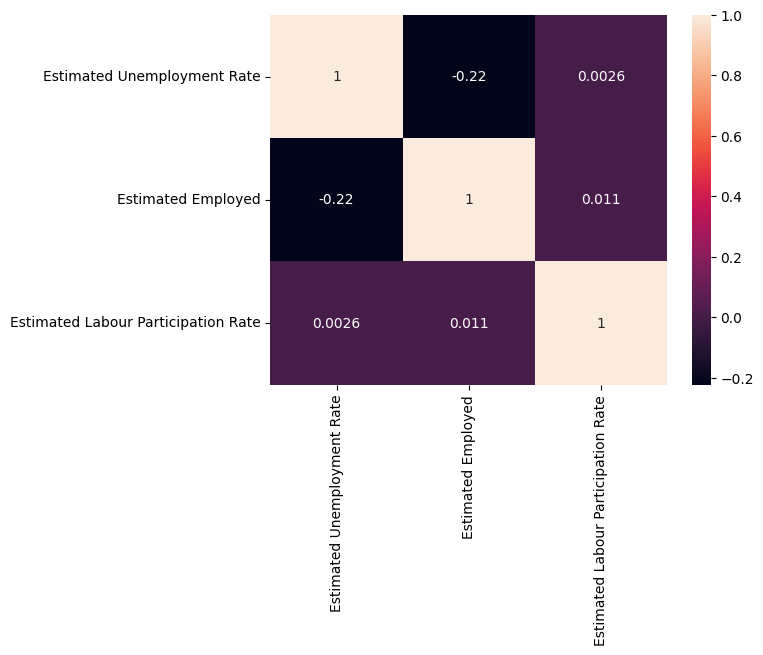

In [22]:
corr = numaric_col.corr() # showing how strongly each numeric column is related to every other column 
sns.heatmap(corr,annot = True)
plt.show()

## Insight

1. Estimated Employed and Unemployment Rate show a negative correlation (-0.22), meaning higher employment is associated with lower unemployment in India.

2. Labour Participation Rate has almost no correlation (0.0026) with the unemployment rate, indicating a very weak relationship.

3. There is a very weak positive correlation (0.011) between employment and labour participation rate.

4. Most correlation values are close to zero, suggesting the variables are largely independent.

5. The results indicate that unemployment in India is influenced by multiple external economic factors beyond these variables.

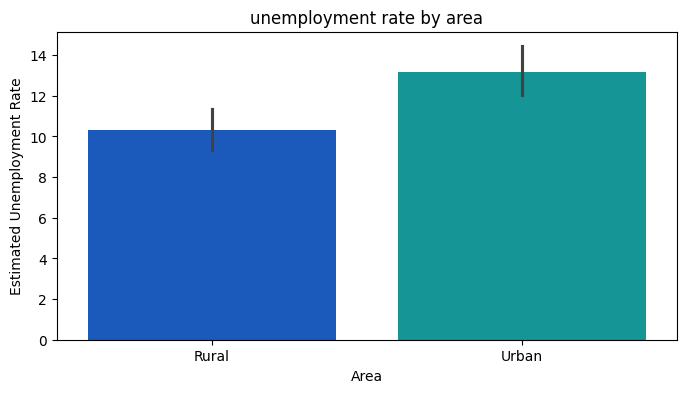

In [23]:
plt.figure(figsize = (8,4))                    #Creates a figure with width 8 inches and height 4 inches.
sns.barplot(x = "Area",y = "Estimated Unemployment Rate",data = clened_df , palette = "winter")
plt.title("unemployment rate by area")            #Adds the title "unemployment rate by area"
plt.show()

## Insight

1. Urban areas show a higher unemployment rate compared to rural areas.

2. The unemployment rate in urban regions is around 13%, while rural areas have about 10%.

3. This suggests that job competition is generally higher in urban labour markets.

5. Rural areas may have lower measured unemployment due to agricultural and informal employment.

6. The data highlights a clear gap between urban and rural employment opportunities in India.

<Axes: xlabel='Estimated Employed', ylabel='Estimated Labour Participation Rate'>

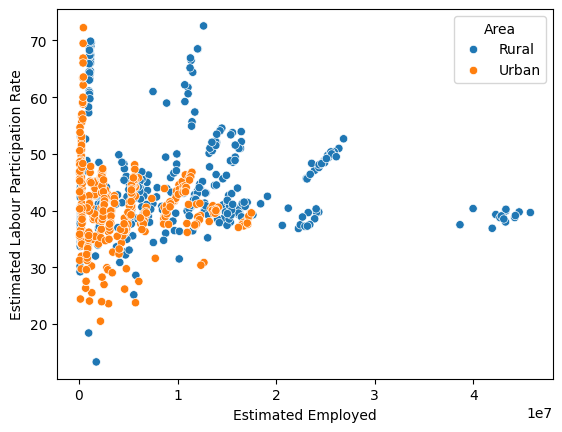

In [24]:
sns.scatterplot(
    x = "Estimated Employed",
    y = "Estimated Labour Participation Rate",
    hue = "Area",
    data = clened_df
    
)     #A scatter plot shows the relationship between two numerical variables by placing points on a graph.

## Insight

1. Rural areas show a wider spread of employment values, indicating larger variation in employment levels compared to urban areas.

2. Urban areas have more clustered data points, suggesting more consistent labour participation rates.

3. Higher employment levels are mostly observed in rural regions, likely due to agriculture and informal sector jobs.

4. Labour participation rates for both rural and urban areas generally fall between 30% and 50%.

5. The scatter distribution suggests there is no strong direct relationship between employment numbers and labour participation rate in India.

area_data = clened_df.groupby("Area")["Estimated Unemployment Rate"].mean()

In [38]:
area_data = clened_df.groupby("Area")["Estimated Unemployment Rate"].mean()

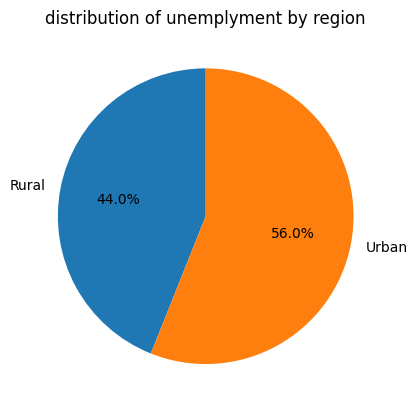

In [39]:
plt.pie(
    area_data,
    labels = area_data.index,
    autopct = "%1.1f%%",
    startangle = 90

)
plt.title("distribution of unemplyment by region")
plt.show()                     #The pie chart shows how unemployment is distributed across different areas (like Urban vs Rural).

## Insight

1. Urban regions account for the larger share of unemployment at about 56%.

2. Rural areas contribute around 44% of the total unemployment distribution.

3. The chart indicates that unemployment is slightly more concentrated in urban areas than in rural areas.

4. Higher urban unemployment may result from greater job competition and migration to cities.

5. The distribution highlights the need for balanced employment opportunities across both rural and urban regions in India.

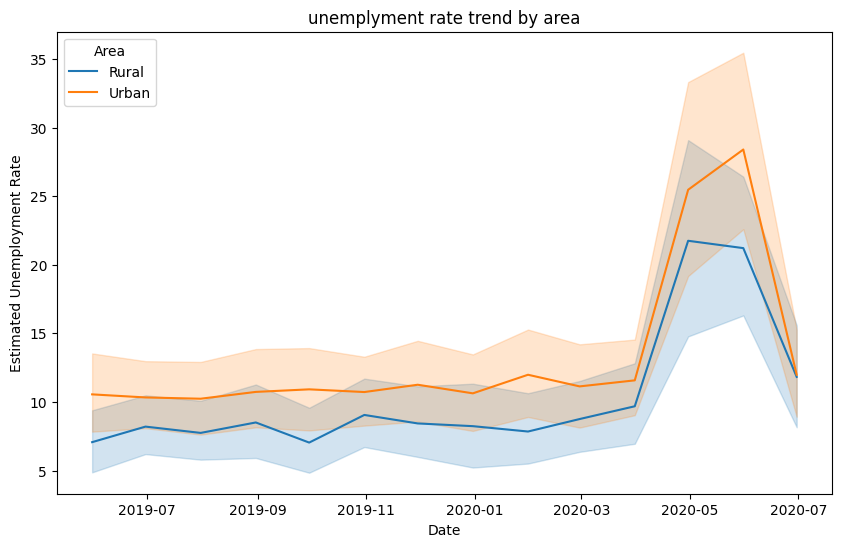

In [34]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x = "Date",
    y = "Estimated Unemployment Rate",
    hue = "Area",
    data = clened_df
)
plt.title("unemplyment rate trend by area")

plt.show()            #How unemployment changes over time
                     #  Differences between Urban and Rural unemployment trends

## Insight 

1. Urban areas consistently show a higher unemployment rate than rural areas throughout the observed period.

2. Both rural and urban unemployment rates remain relatively stable from mid-2019 to early-2020.

3. A sharp increase in unemployment is observed around mid-2020 in both rural and urban regions.

4. Urban unemployment reaches the highest peak (around 35%), while rural unemployment peaks lower (around 30%).

5. After the peak, unemployment rates in both areas decline significantly, indicating gradual labour market recovery in India.

In [27]:
state = clened_df["Region"].unique()[:6]

In [28]:
print(state)

<StringArray>
['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa']
Length: 6, dtype: str


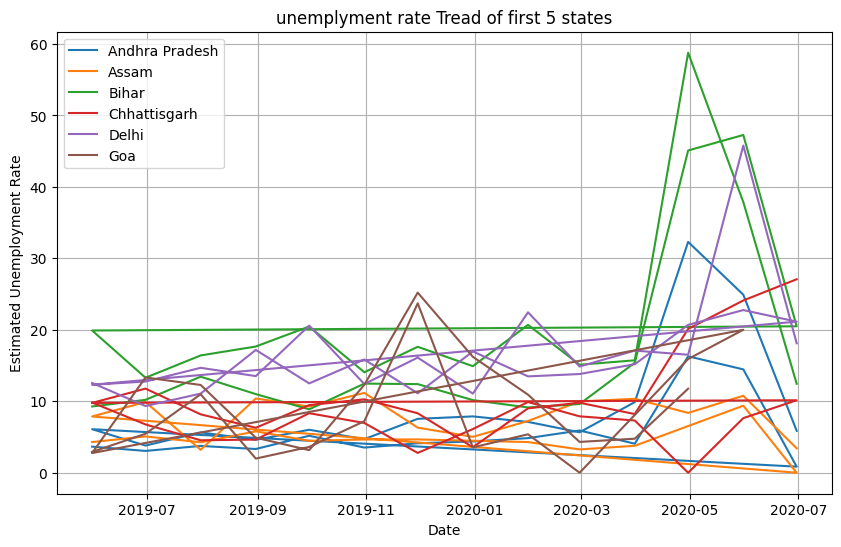

In [29]:
plt.figure(figsize=(10,6))        #Creates a plot area with width 10 and height 6.
for s in state :                  # This loop goes through each state/region in the list state
    data = clened_df[clened_df["Region"] == s]
    plt.plot(data["Date"],data["Estimated Unemployment Rate"], label = s ) #This selects rows where Region = that state.
plt.legend()                     #Shows which line belongs to which state.
plt.title("unemplyment rate Tread of first 5 states")
plt.xlabel("Date")            #Adds title and axis labels
plt.ylabel("Estimated Unemployment Rate")
plt.grid(True)                #Adds background grid lines to make values easier to read.
plt.show()

## Insight
1. Sharp rise during early 2020: Most states show a significant increase in unemployment around April–June 2020, indicating a strong economic disruption during this period.

2. Bihar experienced the highest spike: Bihar shows the largest surge in unemployment, peaking at nearly 60% in May 2020, making it the most affected state in the dataset.

3. Delhi also faced a major increase: Delhi’s unemployment rate rises sharply around May–June 2020, reaching around 45%, suggesting urban job markets were heavily impacted.

4. Assam remained relatively stable: Compared to other states, Assam maintained lower and more stable unemployment rates, generally staying within a smaller range.

5. Fluctuations across smaller states: States like Goa and Chhattisgarh show moderate fluctuations, with occasional spikes but not as extreme as Bihar or Delhi.

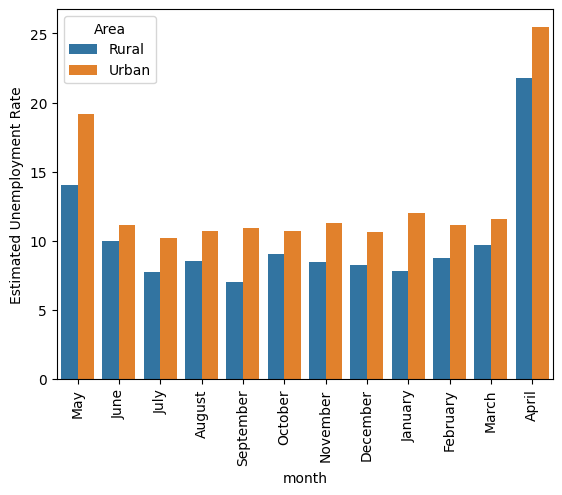

In [30]:
sns.barplot(x = "month",y = "Estimated Unemployment Rate",data = clened_df , hue = "Area",errorbar = None) #This means each month will have multiple bars, one for each area
plt.xticks(rotation = 90) #Rotates the month labels by 90° so they don't overlap and are easier to read.
palette = "summer"
plt.show()

## Insight

1. Urban unemployment is consistently higher than rural unemployment. Across all months, the urban unemployment rate remains above the rural rate, indicating greater job instability in urban areas.

2. A major spike occurs in April. Both rural and urban unemployment rates increase sharply in April, reaching around 22% in rural areas and 25% in urban areas, showing a sudden economic disruption.

3. Lowest unemployment appears around September. Rural unemployment drops to about 7%, while urban unemployment is around 11%, indicating relatively better employment conditions during this period.

4. Urban unemployment shows more fluctuation. Compared to rural areas, urban unemployment rates vary more throughout the months, suggesting urban labor markets are more sensitive to economic changes.

5. Gradual rise before the peak. From January to April, both rural and urban unemployment rates show a gradual upward trend, eventually leading to the sharp increase in April.

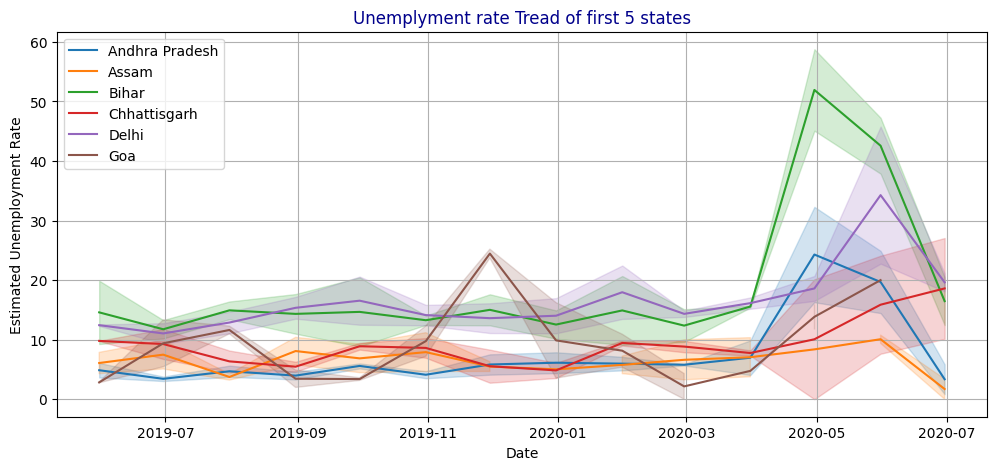

In [41]:
plt.figure(figsize = (12, 5))   # set the size of graph (width, height)

for s in state:   # use loop for disply state one by one
  data = clened_df[clened_df["Region"] == s]
  sns.lineplot(x = "Date", y = "Estimated Unemployment Rate", data = data, label = s)

plt.title("Unemplyment rate Tread of first 5 states", color = "darkblue")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate")

plt.grid(True)
plt.legend()

plt.show()

## conclusion of the overall project

1. The analysis shows that unemployment rates in India vary significantly across different states and regions.

2. Urban areas generally experience higher unemployment rates compared to rural areas due to greater job competition.

3. The data indicates noticeable fluctuations in unemployment trends over the observed months.

4. Some states show stable employment patterns, while others experience sudden spikes in unemployment.

5. A major increase in unemployment is observed during early 2020, indicating a strong economic disruption.
 
6. States like Bihar and Delhi recorded higher peaks compared to other states.

7. Rural unemployment remained relatively lower but still showed variations over time.

8. Urban labor markets appear more sensitive to economic and social changes.

9. The analysis highlights the importance of monitoring unemployment trends for better policy planning.

10. Overall, improving job creation, skill development, and economic stability is essential to reduce unemployment in India.